# Week 8 Lab – Feature Engineering 

This lab contains three parts:

1. **Guided Feature Engineering** – Titanic dataset  
2. **Student Practice** – Tips dataset  
3. **Mini ML Challenge** – Housing price prediction  

**Goal:** Understand how feature engineering improves machine learning models.

> Complete each task in the code cells provided. Do **not** skip steps — each section builds on the previous one.

---
# Part 1 – Guided Feature Engineering (Titanic Dataset)

Follow the steps below to explore and engineer features using the Titanic dataset.

## Step 1 – Import Libraries

Run the cell below to import all required libraries.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Step 2 – Load the Dataset

Run the cell below to load the Titanic dataset using seaborn.

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 3 – Explore the Dataset

**Task:** Use the cells below to explore the dataset.
- Check the shape (number of rows and columns)
- Display data types and non-null counts
- View summary statistics

In [25]:
# TODO: Check the shape of the dataframe
df.shape


(891, 24)

In [4]:
# TODO: Display info about the dataframe (data types)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [ ]:
# TODO: Show summary statistics for numerical columns
df.describe()
# df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone',
 'family_size',
 'is_alone',
 'sex_encoded',
 'embarked_C',
 'embarked_Q',
 'embarked_S',
 'embarked_C',
 'embarked_Q',
 'embarked_S']

### Reflection 1

Based on your exploration above, answer the following:

- **Numerical features:** *(list them here)*
    - age,sibsp,parch,fare,family_size,is_alone,sex_encoded,pclass
- **Categorical features:** *(list them here)*
    - sex,embarked,class,who,adult_male,deck,embark_town,alive
- **Possible target variable:** *(write your answer here)* 
    - survived

## Step 4 – Check Missing Values

**Task:** Find out which columns have missing values and what percentage of data is missing.

In [7]:
# TODO: Count missing values in each column
df.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
# TODO: Calculate the percentage of missing values per column
missing_percent=(df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)
missing_percent

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64

## Step 5 – Handle Missing Values

**Task:** Fill in the missing values appropriately.
- Fill missing `age` values using the **median**
- Fill missing `embarked` values using the **mode**

In [ ]:
# TODO: Fill missing 'age' values with the median age
# Then verify there are no more missing values in 'age'
df['age'] = df['age'].fillna(df['age'].median())


In [ ]:
# TODO: Fill missing 'embarked' values with the most frequent value (mode)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Step 6 – Feature Creation

**Task:** Create two new features:
1. `family_size` — the total number of family members on board (hint: use `sibsp`, `parch`, and add 1 for the passenger themselves)
2. `is_alone` — a binary flag (1 if `family_size == 1`, else 0)

In [ ]:
# TODO: Create 'family_size' column
# Display the first few rows of sibsp, parch, and family_size
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['family_size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 891, dtype: int64

In [20]:
# TODO: Create 'is_alone' column (1 if traveling alone, 0 otherwise)
# Display the first few rows of family_size and is_alone
df['is_alone'] = df['family_size'].apply(lambda x: 1 if x == 1 else 0)
# df['is_alone'] 
df[['sibsp', 'parch', 'family_size', 'is_alone']].head()

,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## Step 7 – Encode Categorical Variables

**Task:** Convert categorical variables into numeric form.
1. Map the `sex` column: `male → 0`, `female → 1`, store as `sex_encoded`
2. Apply one-hot encoding to the `embarked` column using `pd.get_dummies()` with prefix `'embarked'`, and concatenate the result to the dataframe

In [22]:
# TODO: Label-encode the 'sex' column
# Display the first few rows of sex and sex_encoded
df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})
df['sex_encoded']


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: sex_encoded, Length: 891, dtype: int64

In [24]:
# TODO: One-hot encode the 'embarked' column and add to the dataframe
# Display the first few rows of the updated dataframe
embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked')
df = pd.concat([df, embarked_dummies], axis=1)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,alone,family_size,is_alone,sex_encoded,embarked_C,embarked_Q,embarked_S,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,False,2,0,0,False,False,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,False,2,0,1,True,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,True,1,1,1,False,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,False,2,0,1,False,False,True,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,True,1,1,0,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,...,True,1,1,0,False,False,True,False,False,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,...,True,1,1,1,False,False,True,False,False,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,...,False,4,0,1,False,False,True,False,False,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,...,True,1,1,0,True,False,False,True,False,False


## Step 8 – Visualisation

**Task:** Create a count plot showing survival count by gender using `sns.countplot()`.

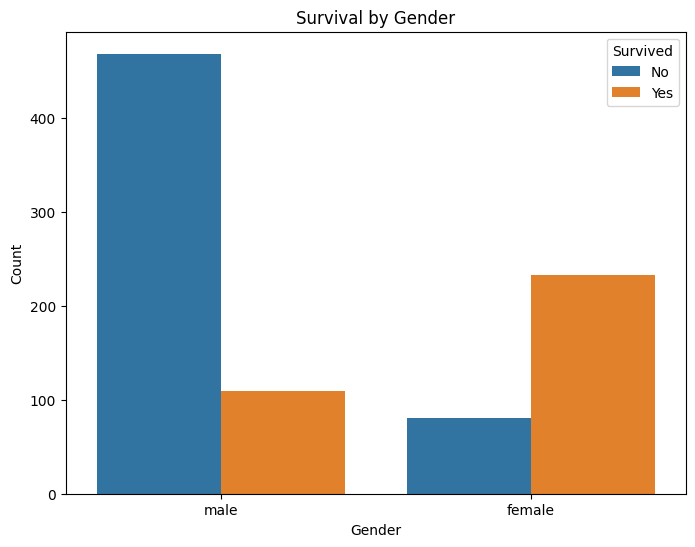

In [28]:
# TODO: Plot survival count by gender
# Add a title: "Survival by Gender"
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### Reflection 2

Based on your plot:

- What do you observe about survival rates by gender?
    - women have high survivied rate compare to men 

- Why might gender be a useful feature for predicting survival?
    - Gender strongly influences survival, so it has high predictive power

*Write your answers here.*


---
# Part 2 – Tips Dataset

Now practice feature engineering **independently** using the Tips dataset. Apply the same skills from Part 1.

## Step 1 – Load and Explore the Dataset

In [29]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [30]:
# TODO: Display info about the tips dataframe
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [31]:
# TODO: Display summary statistics for the tips dataframe
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


### Task 1 – Dataset Identification

Based on your exploration:

- **Numerical features:** *(list them here)*
- **Categorical features:** *(list them here)*
- **Possible target variable:** *(write your answer here)*

## Step 2 – Create New Feature: Tip Percentage

**Task:** Create a new column `tip_percentage` that represents the tip as a fraction of the total bill.

Formula: `tip_percentage = tip / total_bill`

In [33]:
# TODO: Create 'tip_percentage' column
# Display the first few rows of total_bill, tip, and tip_percentage
tips['tip_percentage'] = tips['tip'] / tips['total_bill']
tips[['total_bill', 'tip', 'tip_percentage']].head()

,total_bill,tip,tip_percentage
0,16.99,1.01,0.059447
1,10.34,1.66,0.160542
2,21.01,3.50,0.166587
3,23.68,3.31,0.139780
4,24.59,3.61,0.146808


## Step 3 – Create Group Category Feature

**Task:** Create a `group_category` column:
- `'Small'` if party `size` is less than 4
- `'Large'` if party `size` is 4 or more

In [34]:
# TODO: Create 'group_category' column based on party size
def categorize_group(size):
    if size == 1:
        return 'Solo'
    elif size == 2:
        return 'Couple'
    elif size <= 4:
        return 'Small Group'
    else:
        return 'Large Group'
tips['group_category'] = tips['size'].apply(categorize_group)

# Display the first few rows of size and group_category
tips[['size', 'group_category']].head()


,size,group_category
0,2,Couple
1,3,Small Group
2,3,Small Group
3,2,Couple
4,4,Small Group


## Step 4 – Encode Categorical Variables

**Task:** Encode the following columns:
- `sex`: `Male → 0`, `Female → 1` → store as `sex_encoded`
- `smoker`: `No → 0`, `Yes → 1` → store as `smoker_encoded`

In [36]:
# TODO: Encode 'sex' and 'smoker' columns
tips['sex_encoded'] = tips['sex'].map({'Male': 0, 'Female': 1})
tips['smoker_encoded'] = tips['smoker'].map({'No': 0, 'Yes': 1})
# Display the first few rows of the updated dataframe
tips[['sex', 'sex_encoded', 'smoker', 'smoker_encoded']].head()



,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


## Step 5 – Visualisation

**Task:** Create a box plot showing tip amounts grouped by day of the week.

In [38]:
# TODO: Create a boxplot of tips by day
# Add a title: "Tips by Day"
# plt.figure(figsize=(8,6))
# sns.boxplot(data=tips, x='day', y='tip')

# plt.title('Tips by Day')
# plt.xlabel('Day')
# plt.ylabel('Tip Amount')

# plt.show()
tips.groupby('smoker')['tip'].mean()

smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

### Discussion Questions

Answer the following based on your analysis:

1. **Which day has the highest tips?** *(your answer)*
    - Saturday  shows the highest tips 

2. **Do smokers tip more?** *(your answer — you may use additional code cells below to explore this)*
    - tips.groupby('smoker')['tip'].mean()
    - yes they do
3. **Does group size affect tip percentage?** *(your answer)*
    - Yes — larger groups tend to have lower tip percentage

In [ ]:
# Optional: Add any additional exploration or visualisations here


# Part 3 – Mini Machine Learning Challenge

Apply feature engineering to a **housing dataset** and train a simple machine learning model to predict house prices.

## Step 1 – Load the Dataset

Run the cell below to load the California Housing dataset.

In [40]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [42]:
# TODO: Display info about the housing dataframe
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Step 2 – Feature Engineering

**Task:** Create a new feature `rooms_per_household` by dividing `AveRooms` by `HouseAge`.

> Think about what this ratio might represent. Why could it be useful for predicting house prices?

In [43]:
# TODO: Create 'rooms_per_household' feature
housing_df['rooms_per_household'] = housing_df['AveRooms'] / housing_df['HouseAge']
# Display the first few rows of AveRooms, HouseAge, and rooms_per_household
housing_df[['AveRooms', 'HouseAge', 'rooms_per_household']].head()

,AveRooms,HouseAge,rooms_per_household
0,6.984127,41.0,0.170345
1,6.238137,21.0,0.297054
2,8.288136,52.0,0.159387
3,5.817352,52.0,0.111872
4,6.281853,52.0,0.120805


## Step 3 – Import Machine Learning Libraries

Run the cell below to import the required machine learning tools.

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

## Step 4 – Prepare Features and Target

**Task:**
- Set `X` to all columns **except** `MedHouseVal`
- Set `y` to the `MedHouseVal` column (this is what we want to predict)
- Split the data into training and test sets using an 80/20 split and `random_state=42`

In [45]:
# TODO: Define X (features) and y (target)
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']
# TODO: Split into training and test sets (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 5 – Train the Model

**Task:**
- Create a `LinearRegression` model
- Fit it on the training data
- Generate predictions on the test set

In [49]:
# TODO: Create and train a LinearRegression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# TODO: Generate predictions on the test set
y_pred = lr_model.predict(X_test)

y_pred


array([0.71652342, 1.76188131, 2.7176338 , ..., 4.46271193, 1.18689641,
       2.0054092 ], shape=(4128,))

## Step 6 – Evaluate the Model

**Task:** Calculate the Root Mean Squared Error (RMSE) of your model's predictions.

> RMSE tells us on average how far off our predictions are from the actual values.

In [57]:
# TODO: Calculate and print the RMSE
# Hint: use mean_squared_error(y_test, predictions, squared=False)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

Root Mean Squared Error (RMSE): 0.745


### Extension Challenge (Optional)

Can you improve your RMSE? Try one or more of the following:
- Engineer additional features (e.g., `population_per_household = Population / AveOccup`)
- Remove features that might not be useful
- Try a different model (e.g., `Ridge`, `DecisionTreeRegressor`)

Use the cells below to experiment.

In [ ]:
# Optional: Engineer more features or try a different model


In [ ]:
# Optional: Calculate the new RMSE and compare


---
# Final Reflection

Answer the following questions in your own words:

1. **What is Feature Engineering?**  
   *(Write your answer here)*
   - Feature engineering is the process of creating transforming or selecting input variables  to improve a machine learning model.

2. **Which feature do you think helped the model the most, and why?**  
   *(Write your answer here)*
   - rooms_per_household feature helped model the most because  it combines infomation about avg room and house age which captures living space relative to house age

3. **Why is feature engineering important before training machine learning models?**  
   *(Write your answer here)*
   - Feature engineering can significantly improve model performance by creating more relevant features reducing bad dataset and helping the model capture underlying patterns in the data.